# Assignment No:01
    


In [ ]:
Bhapkar Rajnandini 
EN24107014
AIDS-A(A)

Title01:Create an image classifier using a traditional machine learning approach Random Forest 
and analyze how minor modifications (like noise) affect its predictions. (dataset: MNIST (handwritten digits))

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [3]:
X = X / 255.0

In [4]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=10000,random_state=42)

In [5]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [6]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9674


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       983
           1       0.99      0.99      0.99      1152
           2       0.94      0.97      0.96       967
           3       0.96      0.95      0.95      1034
           4       0.96      0.97      0.97       906
           5       0.98      0.96      0.97       937
           6       0.98      0.99      0.98       961
           7       0.97      0.97      0.97      1055
           8       0.96      0.95      0.96       969
           9       0.96      0.94      0.95      1036

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



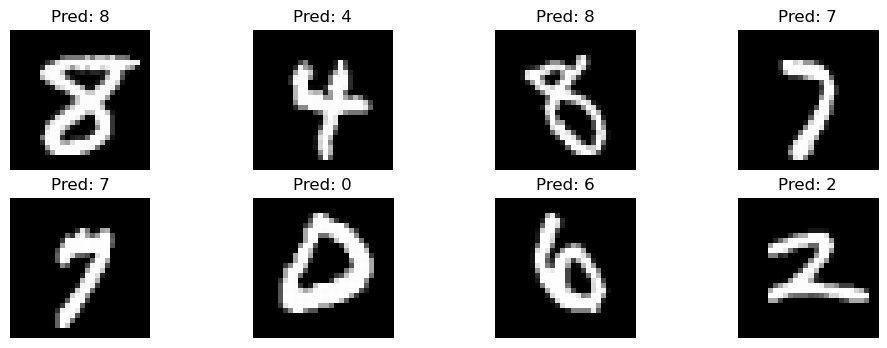

In [8]:
plt.figure(figsize=(12,4))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_test.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title("Pred: {}".format(y_pred[i]))
    plt.axis("off")

plt.show()

In [10]:
def add_noise(images, noise_factor):
    noisy = images + noise_factor * np.random.randn(*images.shape)
    noisy = np.clip(noisy, 0., 1.)
    return noisy

In [11]:
noise_levels = [0.1, 0.2, 0.3, 0.5]

In [12]:
results = []

for noise in noise_levels:

    noisy_images = add_noise(X_test.values, noise)

    pred = rf.predict(noisy_images)

    acc = accuracy_score(y_test, pred)

    results.append(acc)

    print("Noise:", noise, " Accuracy:", acc)

/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Noise: 0.1  Accuracy: 0.7033
Noise: 0.2  Accuracy: 0.6278


/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Noise: 0.3  Accuracy: 0.5615
Noise: 0.5  Accuracy: 0.4623


/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


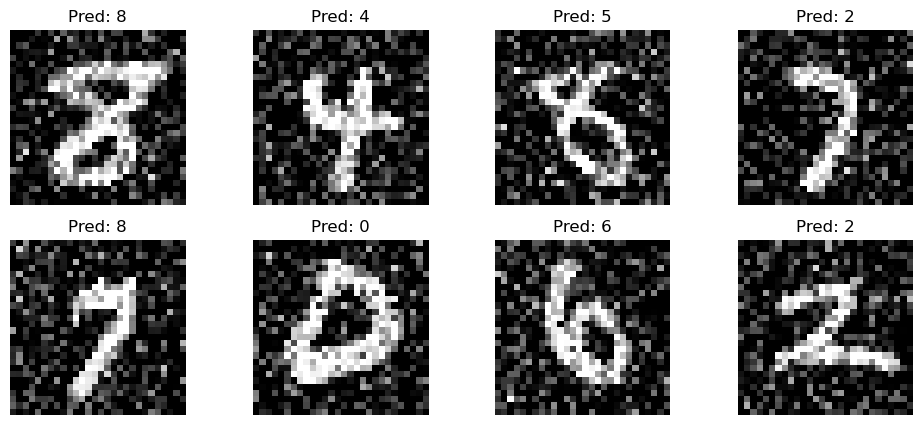

In [13]:
noise = 0.3

noisy = add_noise(X_test.values, noise)

prediction = rf.predict(noisy)

plt.figure(figsize=(12,5))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(noisy[i].reshape(28,28), cmap='gray')

    plt.title("Pred: {}".format(prediction[i]))

    plt.axis('off')

plt.show()

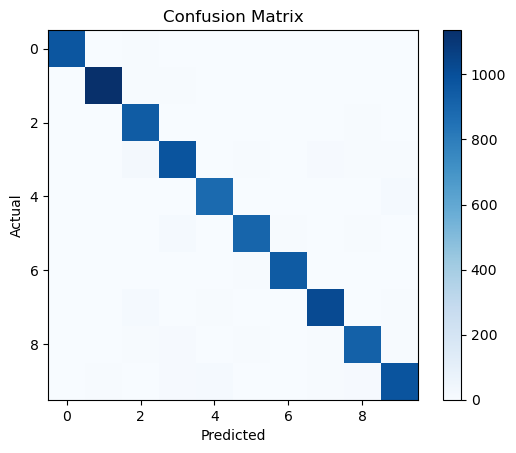

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm, cmap='Blues')

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()